# Dataset EDA

Dataset-level GTEx/AHBA coverage, demographic, and pre/post harmonization diagnostics.


## Table of Contents

- 1) Dataset Attributes
- GTEx Demographics
- 2) Pre/Post ComBat Diagnostics


In [1]:
from pathlib import Path
import sys
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.eval_utils.eda_core import *


In [2]:
import importlib
import src.eval_utils.eda_core as eda_core
importlib.reload(eda_core)
from src.eval_utils.eda_core import *


In [3]:
set_academic_style()

CFG = EDAConfig(
    csv_path='data/raw/gxp_samples.csv',
    cache_root='out/loro_subject_cache_c',  # 'out/loro_subject_cache_c' (centroids) | 'out/loro_subject_cache_cv' (centroids_and_volumes)
    gene_scope='allgenes',
)
CFG
print('analysis scope:', CFG.gene_scope)

analysis scope: allgenes


## 1) Dataset Attributes


In [4]:
PREPOST = prepare_pre_post_harmonization_cached(CFG)
print('subjects:', len(PREPOST['subjects']))
print('genes:', len(PREPOST['genes']))
print('parcels:', PREPOST['raw_cube'].shape[1])


subjects: 318
genes: 13618
parcels: 150


## GTEx Demographics

GTEx rows are donor-tissue samples, so demographic counts are collapsed to one row per subject before plotting.


,subject,age,sex
0,GTEX-1117F,64,F
1,GTEX-111FC,64,M
2,GTEX-1128S,64,F
3,GTEX-117XS,64,M
4,GTEX-117YW,54,M


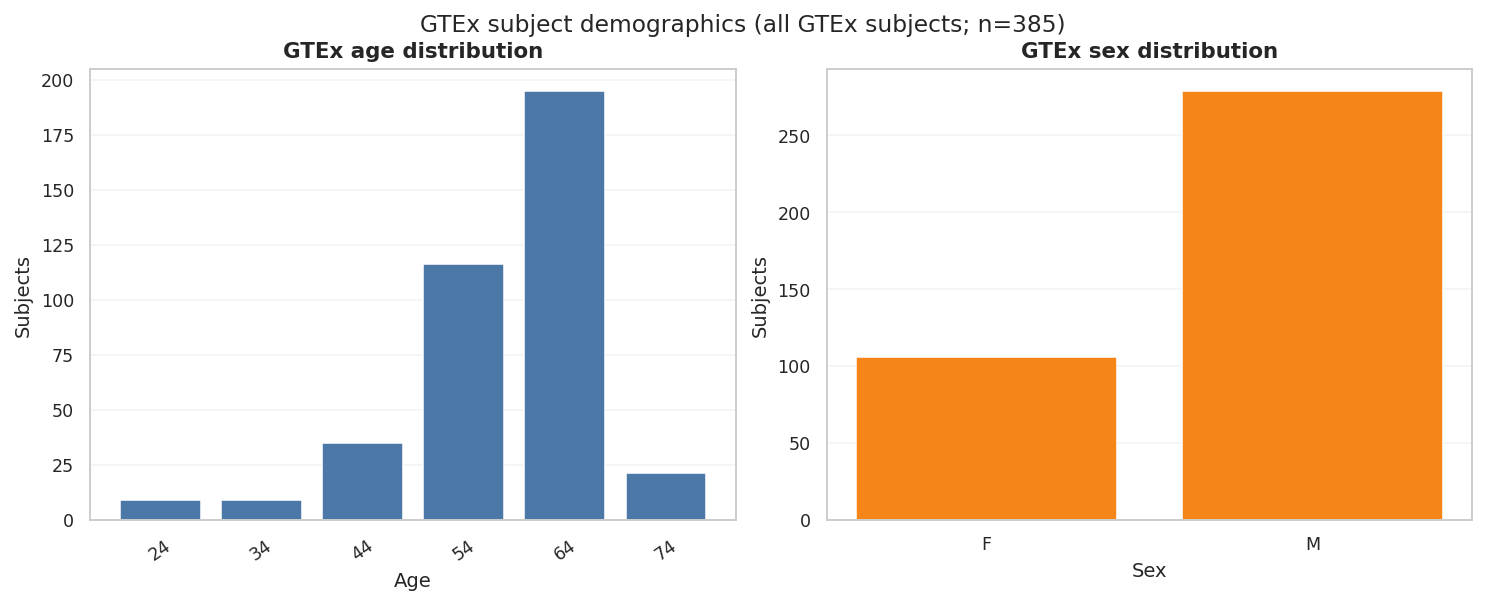

In [5]:
fig, axes, gtex_demo_df = plot_gtex_demographic_breakdown(PREPOST, eligible_only=False)
display(gtex_demo_df.head())


,subject,age,sex
0,GTEX-1117F,64,F
1,GTEX-111FC,64,M
2,GTEX-117XS,64,M
3,GTEX-1192W,64,M
4,GTEX-1192X,54,M


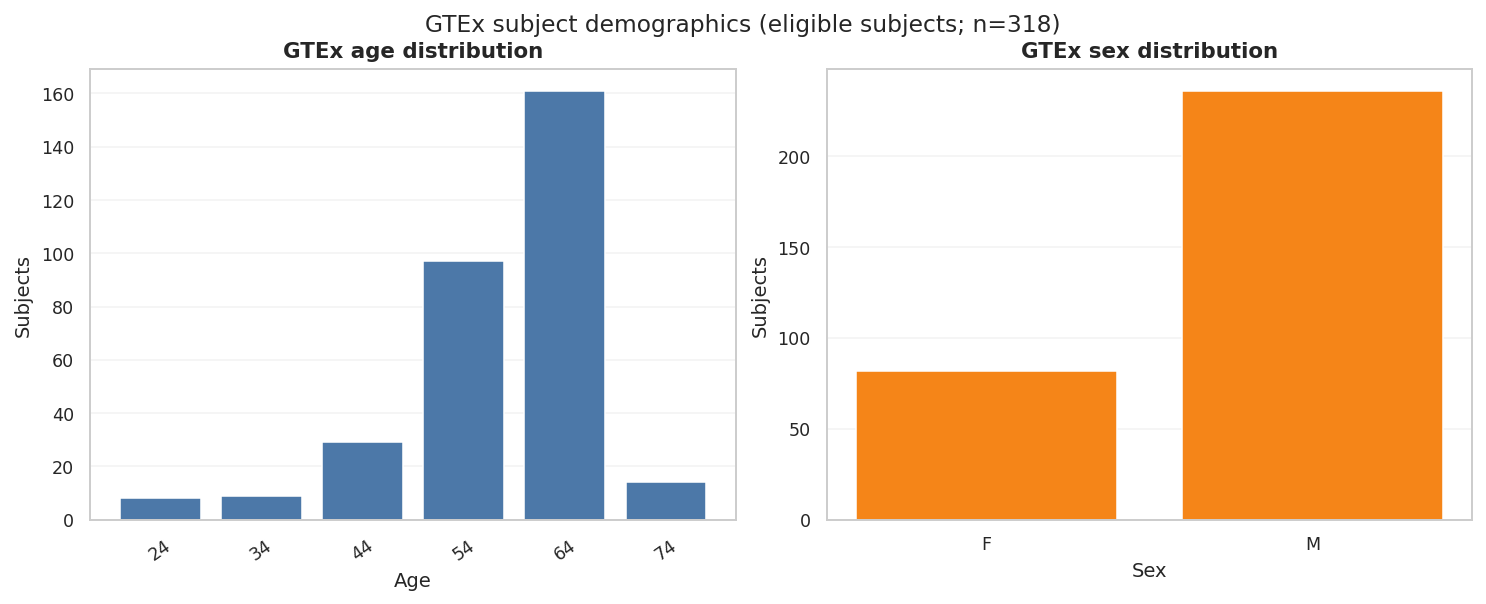

In [17]:
fig, axes, gtex_demo_df = plot_gtex_demographic_breakdown(PREPOST, eligible_only=True)
display(gtex_demo_df.head())


In [6]:
# label_mode: 'ahba' | 'gtex' | 'both'
LABEL_MODE = 'both'
ELIGIBLE_ONLY = True

count_df = parcel_subject_count_table(PREPOST, label_mode=LABEL_MODE, eligible_only=ELIGIBLE_ONLY)
n_pool = int(count_df['n_subjects_pool'].iloc[0])
print(f'n (subjects in pool) = {n_pool}; eligible_only={ELIGIBLE_ONLY}')
count_df[['parcel_idx','ahba_parcel','gtex_native','n_subjects_observed','n_samples','label']].head(12)


n (subjects in pool) = 318; eligible_only=True


,parcel_idx,ahba_parcel,gtex_native,n_subjects_observed,n_samples,label
0,10,LH-Ca,caudate (basal ganglia),279,279,LH-Ca: caudate (basal ganglia)
1,18,LH-NAC,nucleus accumbens (basal ganglia),273,273,LH-NAC: nucleus accumbens (basal ganglia)
2,5,Cerebellar_Region5,cerebellar hemisphere,262,262,Cerebellar_Region5: cerebellar hemisphere
3,38,LH_Default_PFC_5,frontal cortex (ba9),252,252,LH_Default_PFC_5: frontal cortex (ba9)
4,0,Cerebellar_Region1,cerebellum,251,251,Cerebellar_Region1: cerebellum
5,19,LH-Pu,putamen (basal ganglia),250,250,LH-Pu: putamen (basal ganglia)
6,16,LH-HTH,hypothalamus,242,242,LH-HTH: hypothalamus
7,31,LH_Cont_PFCl_1,cortex,240,240,LH_Cont_PFCl_1: cortex
8,55,LH_Hippocampus,hippocampus,240,240,LH_Hippocampus: hippocampus
9,132,RH_SalVentAttn_Med_2,anterior cingulate cortex (ba24),223,223,RH_SalVentAttn_Med_2: anterior cingulate corte...


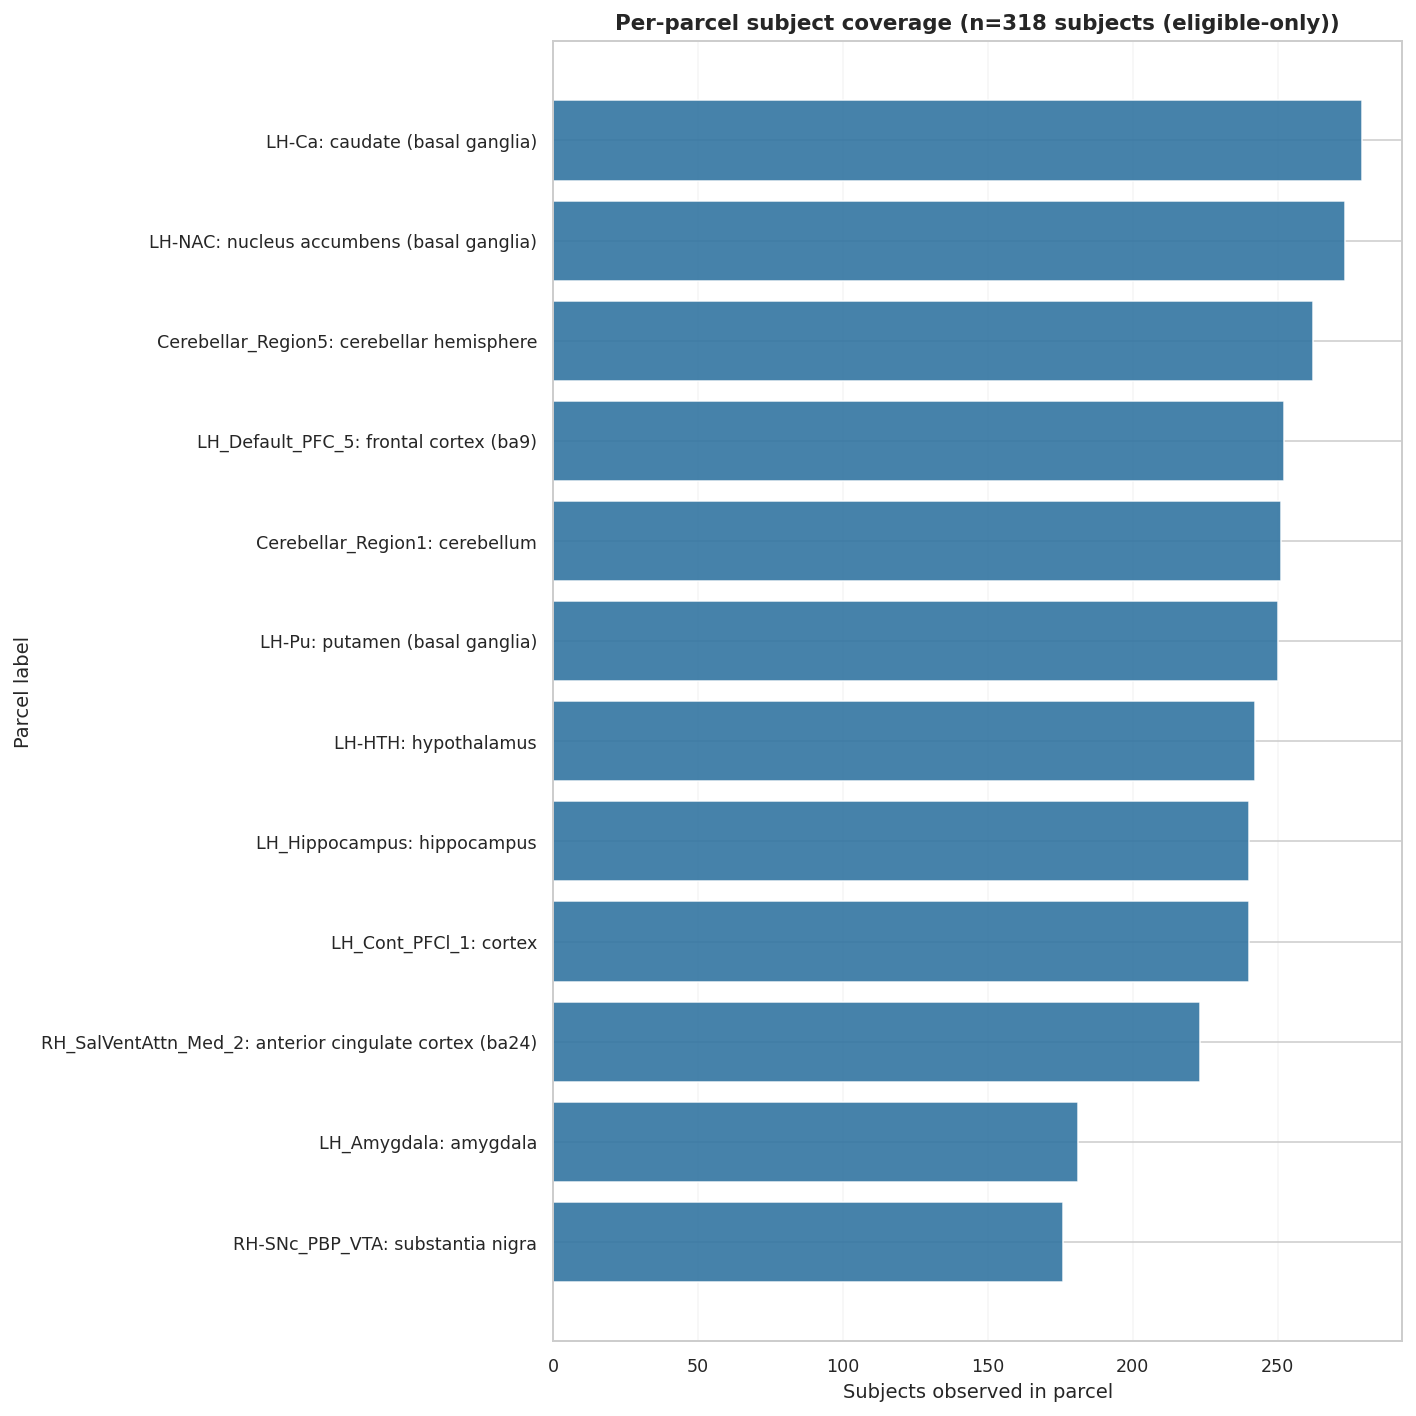

In [7]:
fig_h = max(8.0, 0.20 * len(count_df))
fig, ax = plot_parcel_subject_counts(count_df, top_n=None, min_subjects=1, figsize=(10, 10))


,n_regions_sampled,n_subjects,eligible_only,n_subjects_pool
0,5,21,True,318
1,6,29,True,318
2,7,36,True,318
3,8,29,True,318
4,9,53,True,318
5,10,54,True,318
6,11,63,True,318
7,12,33,True,318


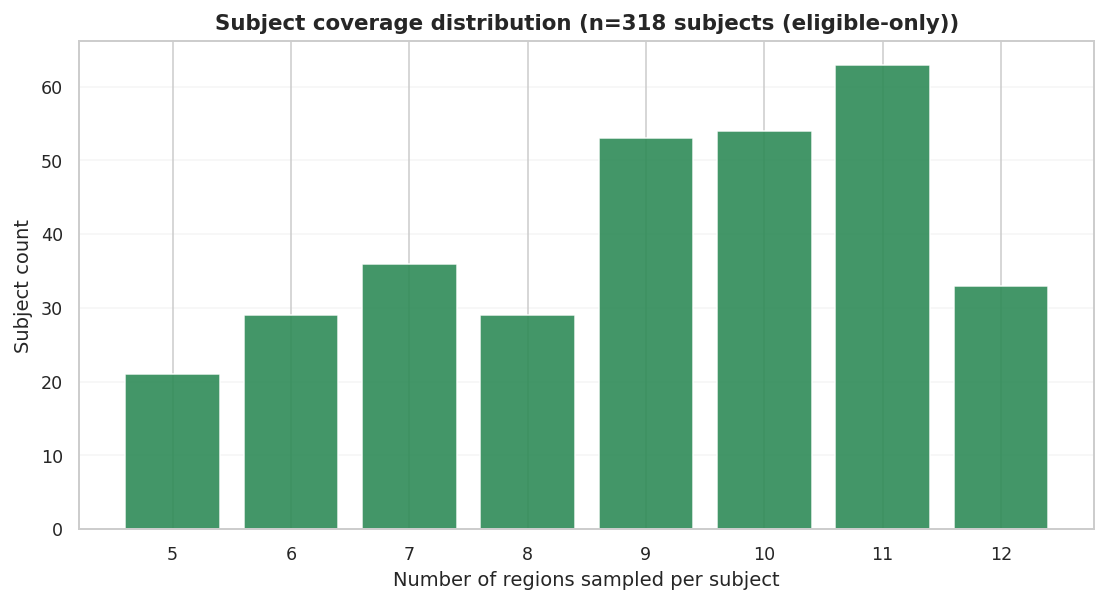

In [8]:
# LORO-relevant: x=regions sampled per subject, y=subject count
subj_cov = subject_region_count_distribution(PREPOST, eligible_only=ELIGIBLE_ONLY)
display(subj_cov)
fig, ax = plot_subject_region_count_distribution(subj_cov)


In [9]:
CSV_PATH = "data/raw/gxp_samples.csv"
gxp_samples_df = pd.read_csv(CSV_PATH)


/tmp/ipykernel_1503829/4168357976.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  gxp_samples_df = pd.read_csv(CSV_PATH)


Quick calls for writing gene lists

In [ ]:
# from data.utils import (
#     build_and_write_hvg_gene_list,
#     build_and_write_tissue_deg_gene_list,
# )

# # GTEx HVGs: default tissue-discriminative
# out_path, ranked = build_and_write_hvg_gene_list(
#     samples_df=gxp_samples_df,
#     dataset="GTEx",
#     method="variance",
#     n_genes=100,
# )
# print("wrote", out_path)

# # GTEx HVGs: within-tissue / demeaned alternative
# out_path, ranked = build_and_write_hvg_gene_list(
#     samples_df=gxp_samples_df,
#     dataset="GTEx",
#     method="demeaned",
#     n_genes=100,
#     out_name=f"gtex_100hvg_demeaned.txt",
# )
# print("wrote", out_path)

# # GTEx tissue-enriched DEG panel: top 10 per tissue
# deg_path, deg_ranked = build_and_write_tissue_deg_gene_list(
#     samples_df=gxp_samples_df,
#     dataset="GTEx",
#     top_k_per_group=25,
#     out_name="gtex_25deg.txt",
# )
# print("wrote", deg_path)
# display(deg_ranked.head(24))


## 2) Pre/Post ComBat Diagnostics


In [11]:
# gene_mode: 'allgenes' | 'custom'
# Use gene_mode='custom' with eval_gene_list_path for named panels such as 'gtex_100hvg'.
GENE_MODE = 'custom'
EVAL_GENE_LIST_PATH = 'gtex_100hvg'
CUSTOM_GENE_LIST = None

atlas_cmp_mean = prepare_atlas_median_comparison(
    PREPOST,
    gene_mode=GENE_MODE,
    custom_gene_list=CUSTOM_GENE_LIST,
    eval_gene_list_path=EVAL_GENE_LIST_PATH,
    observed_only=True,
    summary_stat='mean',
)
atlas_cmp = prepare_atlas_median_comparison(
    PREPOST,
    gene_mode=GENE_MODE,
    custom_gene_list=CUSTOM_GENE_LIST,
    eval_gene_list_path=EVAL_GENE_LIST_PATH,
    observed_only=True,
    summary_stat='median',
)
print('atlas parcels:', len(atlas_cmp['parcel_labels']))
print('genes in panel:', len(atlas_cmp['genes']))


atlas parcels: 12
genes in panel: 88


### Mean Matrix Comparison


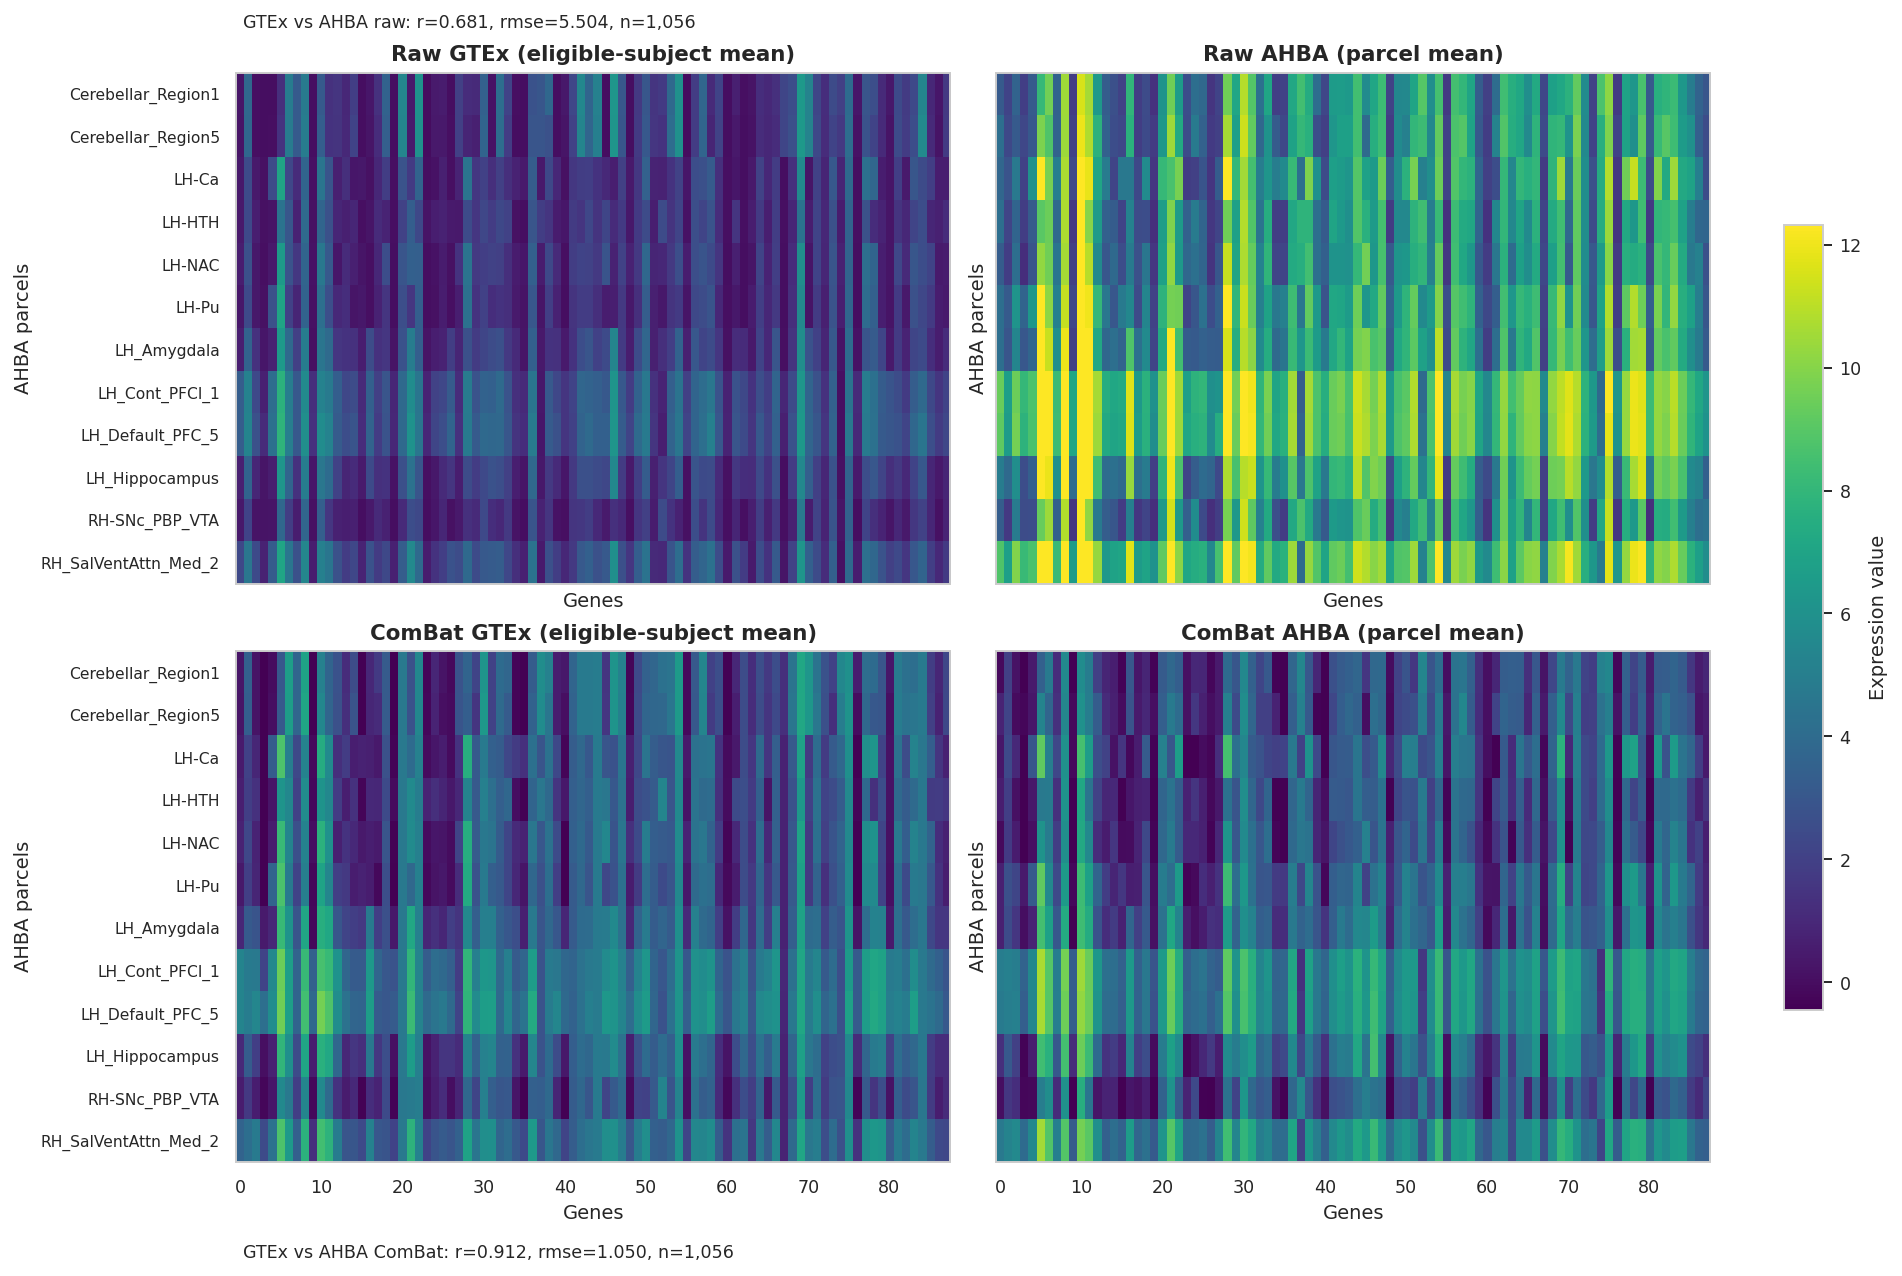

In [12]:
fig, axes = plot_atlas_median_comparison_heatmaps(atlas_cmp_mean, label_stride=1)


### Median Matrix Comparison


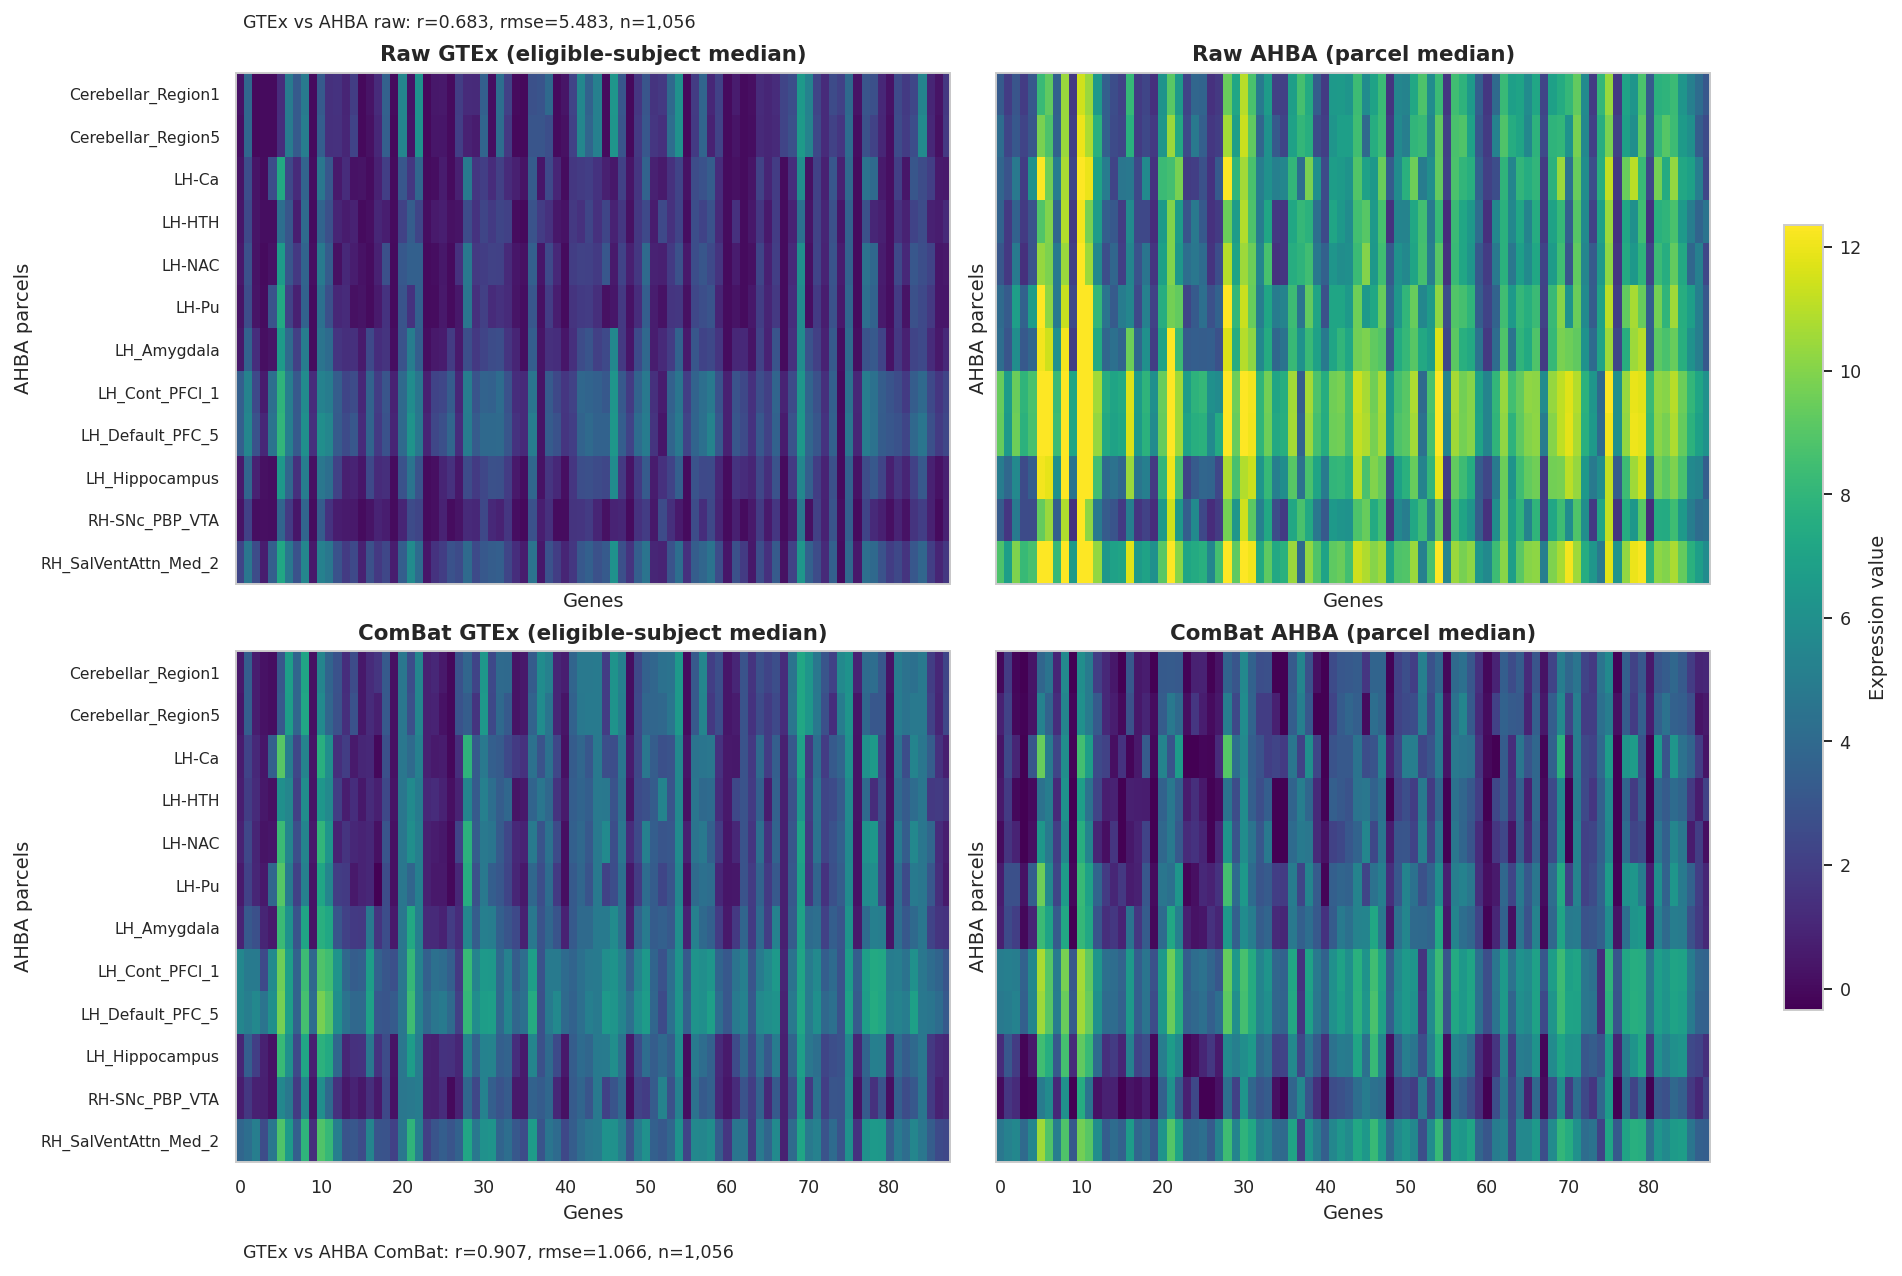

In [13]:
fig, axes = plot_atlas_median_comparison_heatmaps(atlas_cmp, label_stride=1)


### Single Subjects Pre-Post Combat Matrix Comparison


subject: GTEX-1117F
subject: GTEX-111FC
subject: GTEX-11EMC


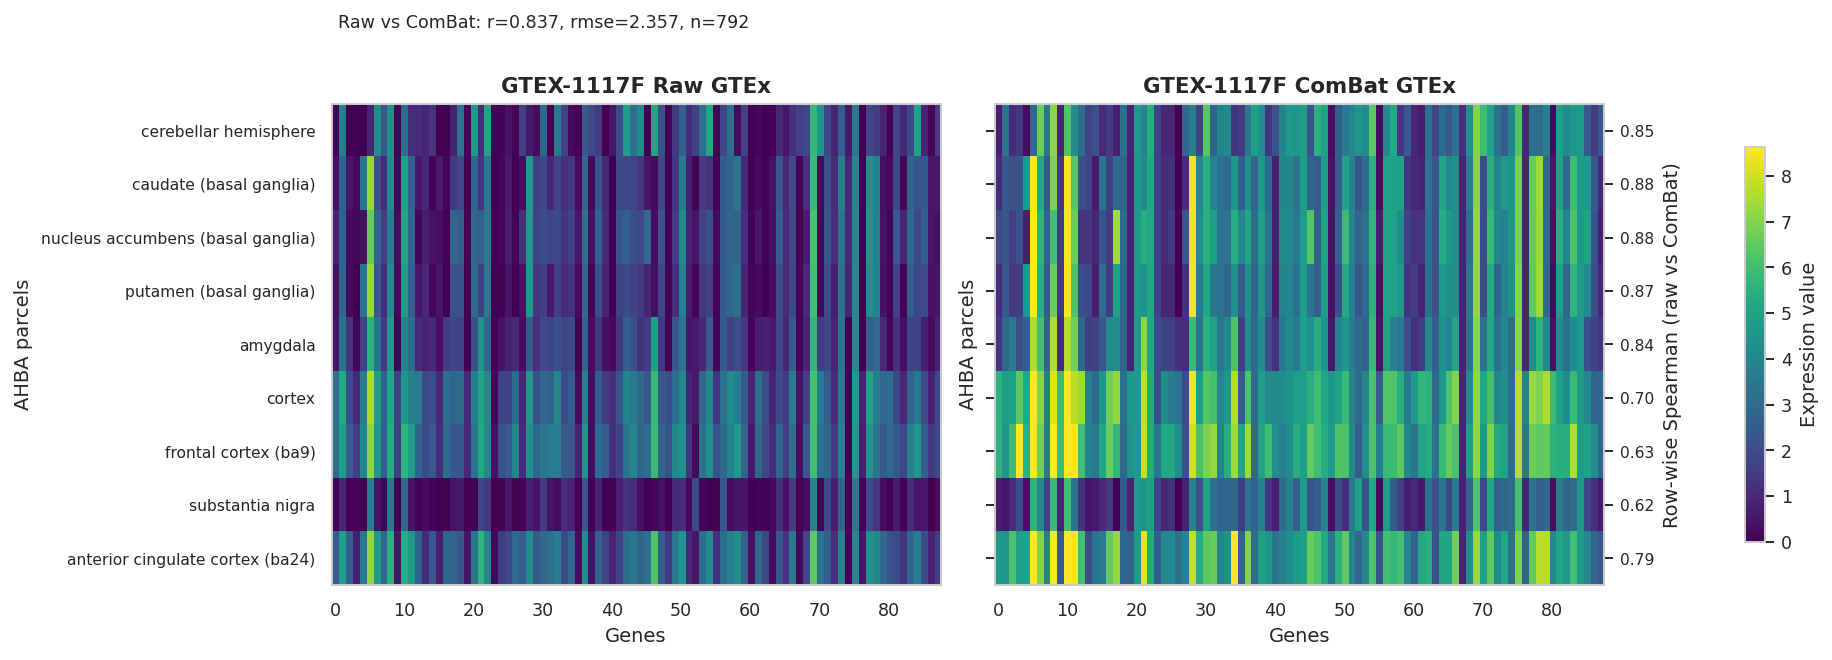

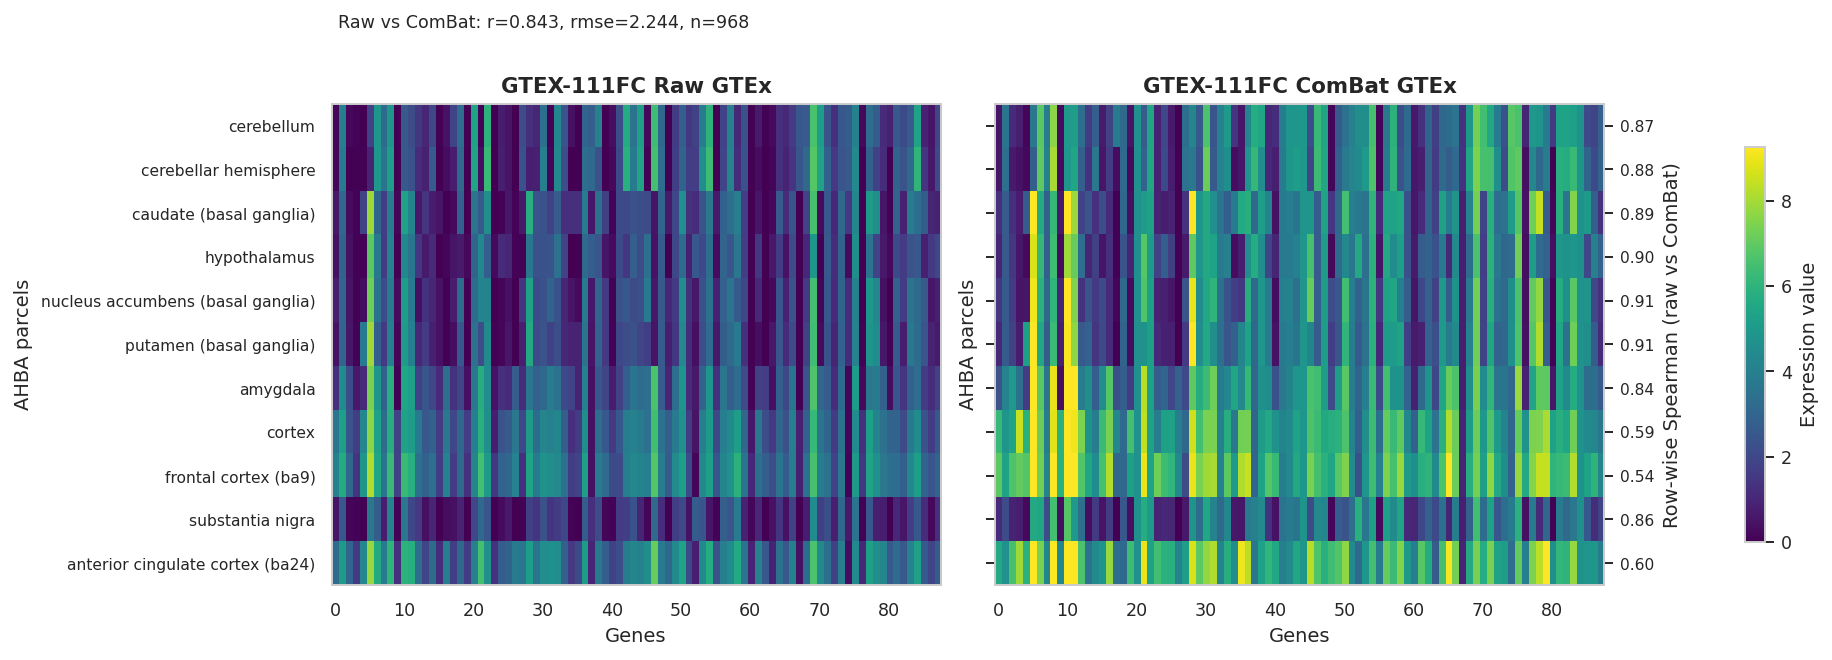

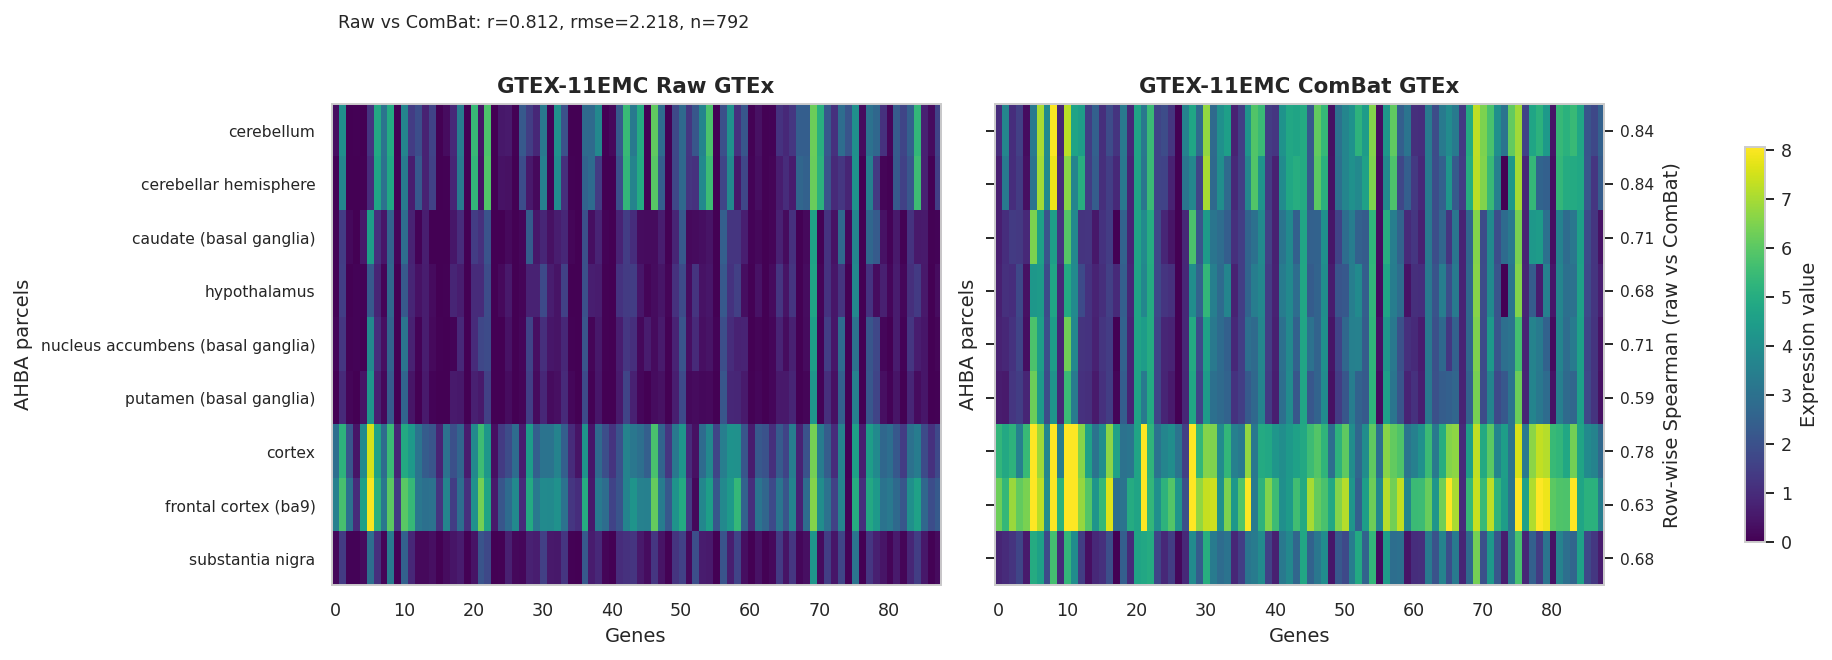

In [23]:
# Single-subject pre/post (GTEx only)
SUBJECT_ID = PREPOST['subjects'][0]
fig, axes = plot_subject_prepost_heatmaps(
    PREPOST,
    subject_id=SUBJECT_ID,
    gene_mode=GENE_MODE,
    custom_gene_list=CUSTOM_GENE_LIST,
    eval_gene_list_path=EVAL_GENE_LIST_PATH,
    observed_only=True,
    label_stride=1,
)
print('subject:', SUBJECT_ID)

# Single-subject pre/post (GTEx only)
SUBJECT_ID = PREPOST['subjects'][1]
fig, axes = plot_subject_prepost_heatmaps(
    PREPOST,
    subject_id=SUBJECT_ID,
    gene_mode=GENE_MODE,
    custom_gene_list=CUSTOM_GENE_LIST,
    eval_gene_list_path=EVAL_GENE_LIST_PATH,
    observed_only=True,
    label_stride=1,
)
print('subject:', SUBJECT_ID)

# Single-subject pre/post (GTEx only)
SUBJECT_ID = PREPOST['subjects'][10]
fig, axes = plot_subject_prepost_heatmaps(
    PREPOST,
    subject_id=SUBJECT_ID,
    gene_mode=GENE_MODE,
    custom_gene_list=CUSTOM_GENE_LIST,
    eval_gene_list_path=EVAL_GENE_LIST_PATH,
    observed_only=True,
    label_stride=1,
)
print('subject:', SUBJECT_ID)


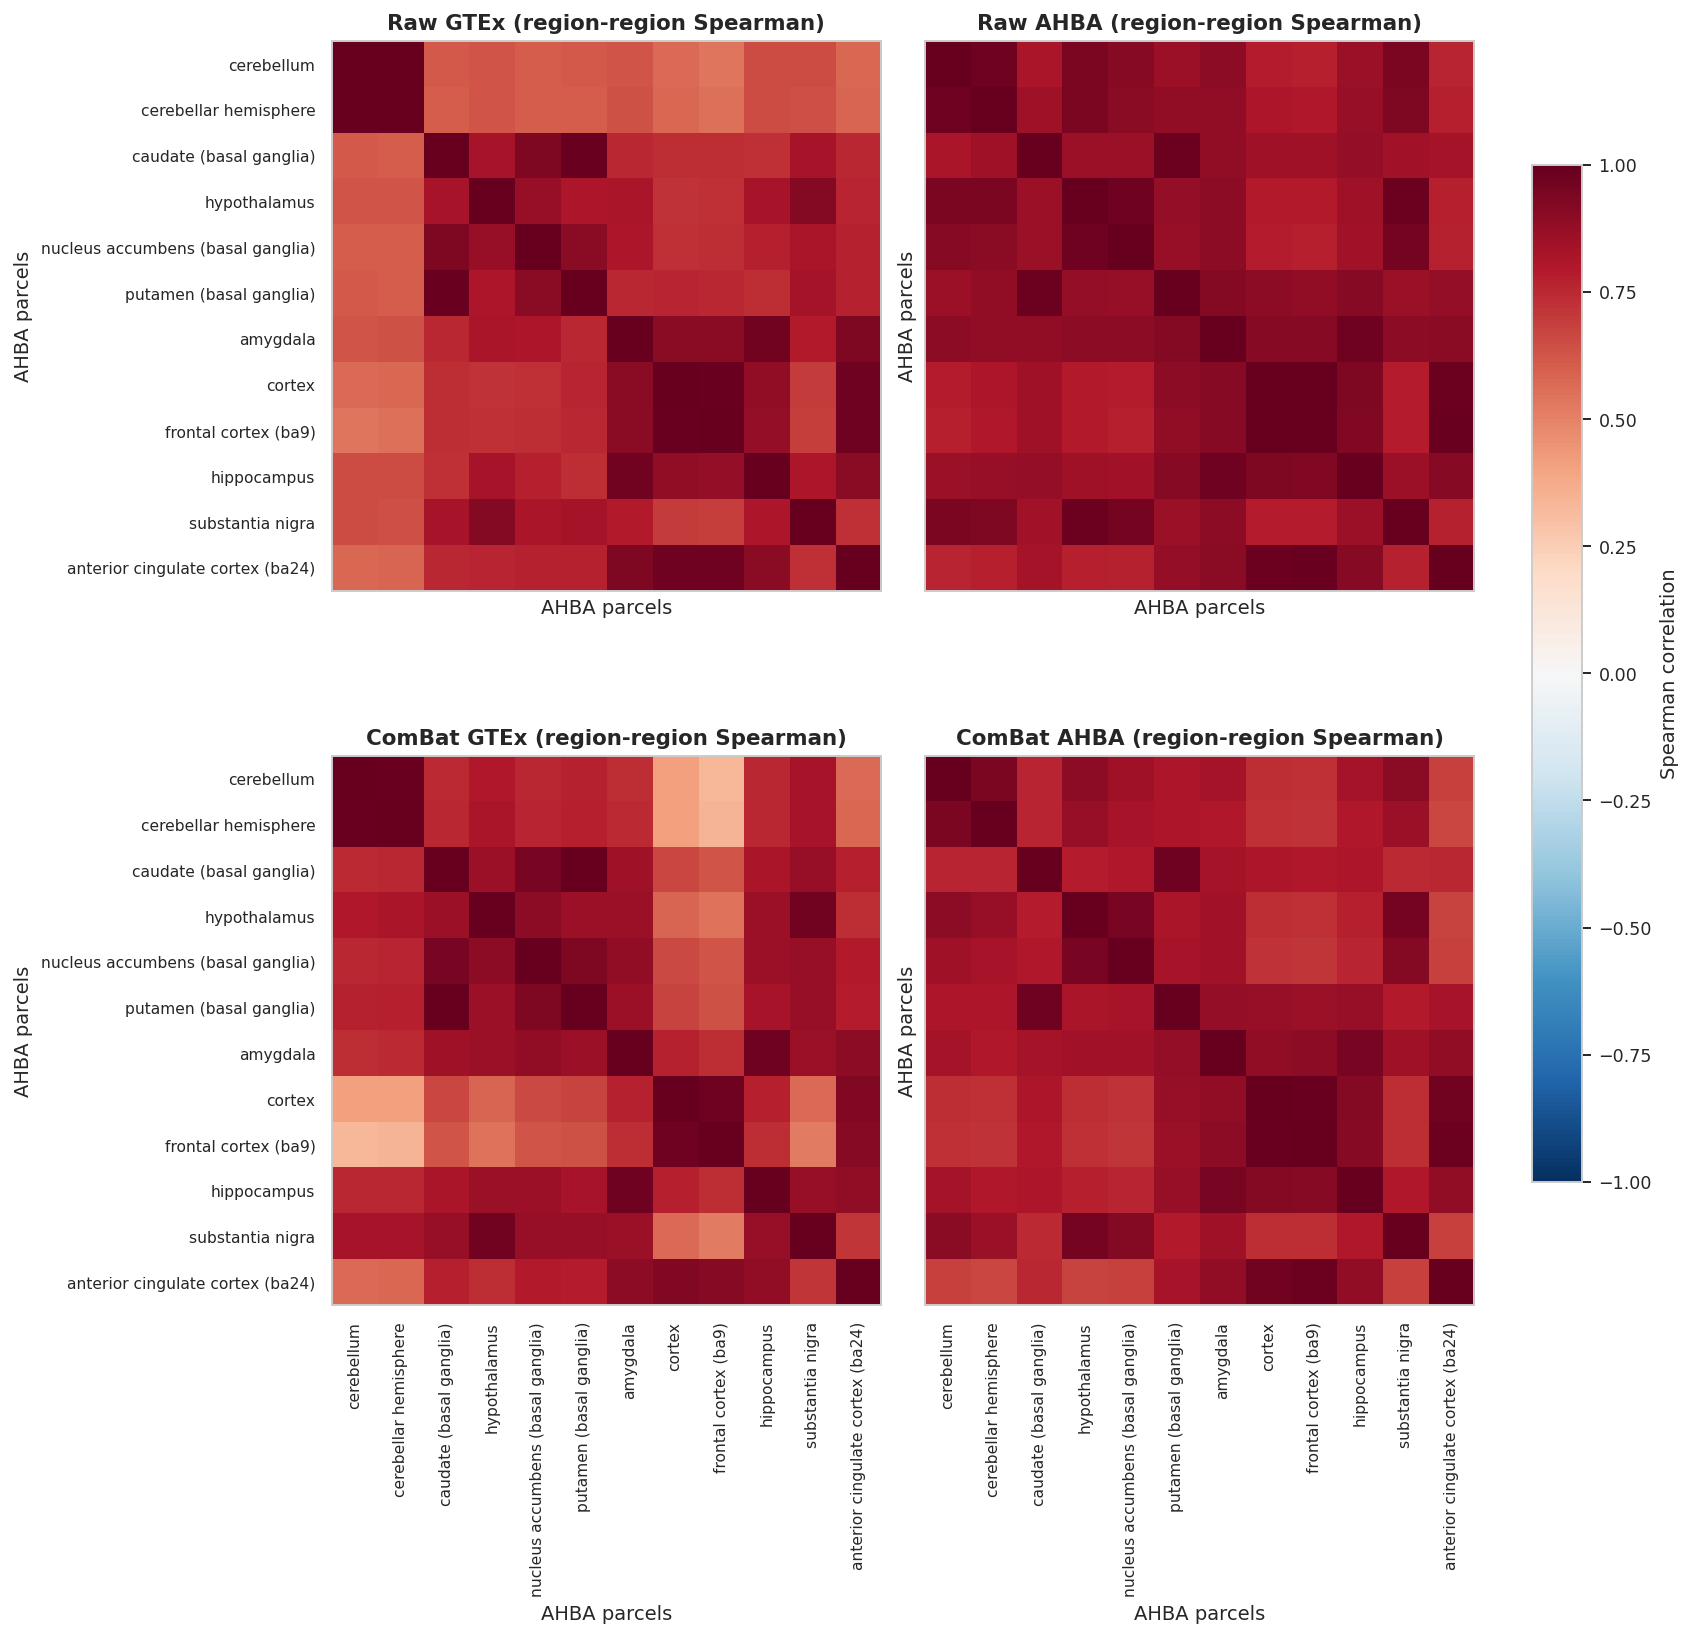

In [21]:
fig, axes = plot_region_region_spearman_heatmaps(atlas_cmp)


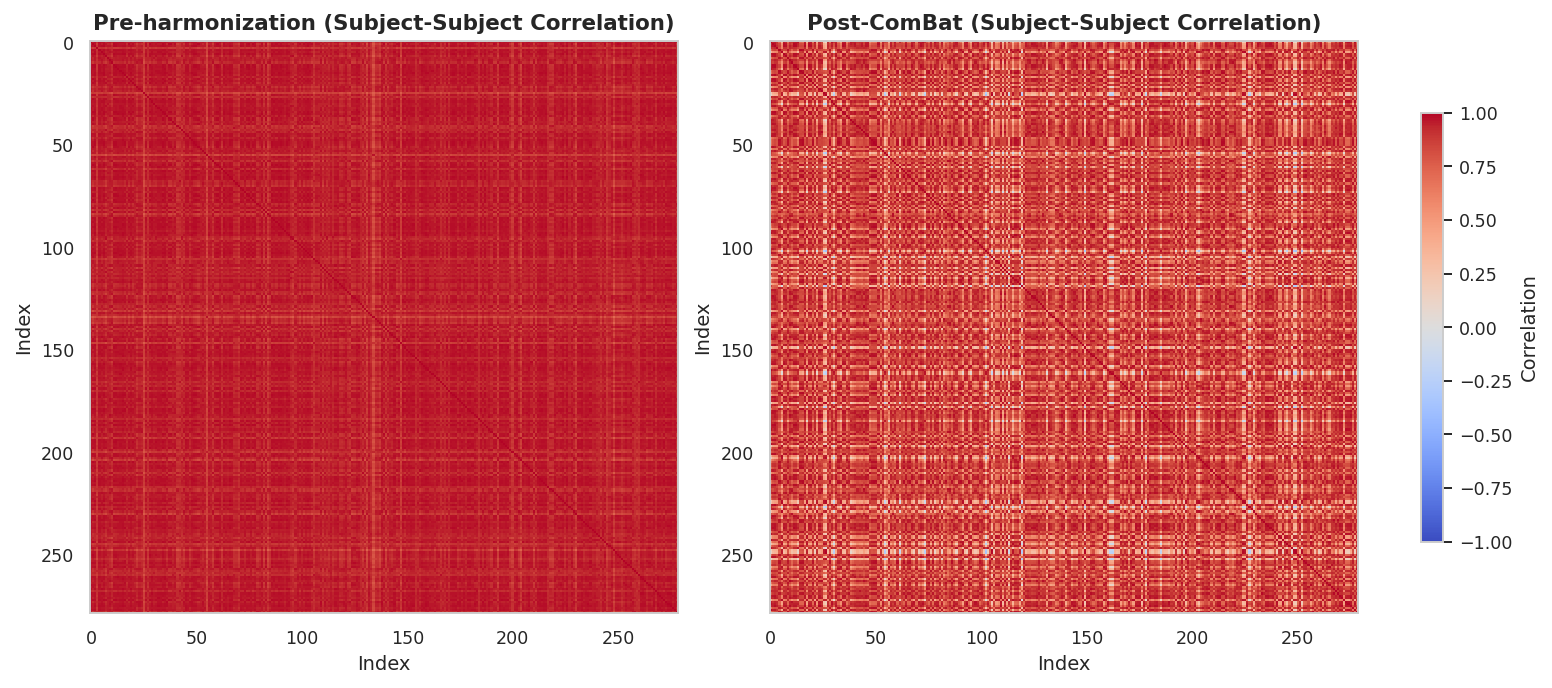

In [22]:
# Optional population-level region-wise subject-subject pre/post view
avail = available_regions(PREPOST, min_subjects=1)
REGION = int(avail.iloc[0]['parcel_idx'])
fig, axes = plot_region_covariance_side_by_side(PREPOST, region=REGION, mode='subject')
